# 06 — SHAP & interpretação do modelo

> etapa 4c do Datathon FIAP fase 5 — associação Passos Mágicos

## por que esse notebook existe

o modelo do 04 (LogReg) bateu XGBoost e LightGBM por PR-AUC e foi escolhido como modelo final. mas modelo bom sem explicação não vira ação. a Passos Mágicos não vai colocar tutor pra ligar pra um aluno só porque "o modelo disse" — a coordenadora pedagógica precisa ver por quê.

esse notebook traduz o modelo em narrativa interpretável usando 3 técnicas complementares:

| # | técnica | o que responde |
|---|---|---|
| 1 | permutation importance | "quão importante cada feature é, na prática?" (robusto a colinearidade) |
| 2 | SHAP global (LinearExplainer no LogReg) | "como cada feature empurra a probabilidade de risco?" |
| 3 | SHAP global (TreeExplainer em XGBoost auxiliar) | "modelo não-linear concorda com a leitura linear? captura interações que o LogReg perde?" |
| 4 | SHAP local (3 alunos exemplares) | "por que esse aluno específico foi flegado vermelho?" |

## o que sai daqui

- top features globais (ranking robusto, não dependente de coeficiente bruto)
- 3 figuras SHAP prontas pra apresentação executiva
- 3 force plots locais (1 verde, 1 amarelo, 1 vermelho) — esses vão direto pro ppt
- sanity de consistência LogReg VS XGBoost — se as duas técnicas concordam, a interpretação é defensável

## decisão metodológica importante

vou explicar o modelo final (LogReg), mas treinei um XGBoost auxiliar só pra cruzar as interpretações. não troquei o modelo final — XGBoost aqui é apenas "segunda opinião". se o ranking de features do XGBoost bater com o do LogReg, ganhei confiança. se divergir, é um alerta de que o LogReg pode estar capturando colinearidade espúria.

## 1. setup e carregamento

carreguei:
- o modelo final do 04 (`modelo_risco_v1.pkl`) — pipeline completo com imputer + scaler + LogReg
- os thresholds operacionais (observação / atenção / urgente)
- os datasets persistidos no 03 (x_train, x_test, y_train, y_test) + metadados pra análise local
- a lista canônica de features (24 colunas, na ordem que o modelo espera)

e rodei um sanity check: predict no teste e conferi que ROC-AUC e métricas batem com o que vi no 04. se não bater, tem alguma coisa estranha (modelo regravado, dataset alterado) e eu para aqui antes de gastar SHAP em modelo errado.

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
)

# Setup visual consistente com os outros notebooks
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

# === Paths ===
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# === Carregar datasets do 03 ===
X_train = pd.read_parquet(DATA_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DATA_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DATA_PROCESSED / "y_train.parquet")["risco"].values
y_test = pd.read_parquet(DATA_PROCESSED / "y_test.parquet")["risco"].values
meta_test = pd.read_parquet(DATA_PROCESSED / "teste_metadata.parquet")

# === Carregar modelo final do 04 ===
modelo = joblib.load(MODELS_DIR / "modelo_risco_v1.pkl")

with open(MODELS_DIR / "thresholds.json") as f:
    thresholds = json.load(f)

with open(MODELS_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

# === Conferência das colunas ===
assert list(X_test.columns) == feature_names, (
    "X_test não está na ordem esperada pelo modelo. "
    "Rode novamente os notebooks 03 e 04."
)

print(f"✅ Modelo carregado:        {thresholds['modelo_selecionado']}")
print(f"✅ Features esperadas:      {len(feature_names)}")
print(f"✅ X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"✅ Classe 1 — treino: {y_train.mean():.1%}  |  teste: {y_test.mean():.1%}")
print()
print(f"Thresholds operacionais:")
print(f"  🟢 Observação: {thresholds['observacao']:.4f}")
print(f"  🟡 Atenção:    {thresholds['atencao']:.4f}")
print(f"  🔴 Urgente:    {thresholds['urgente']:.4f}")

✅ Modelo carregado:        LogReg
✅ Features esperadas:      24
✅ X_train: (860, 24)  |  X_test: (1014, 24)
✅ Classe 1 — treino: 59.7%  |  teste: 59.5%

Thresholds operacionais:
  🟢 Observação: 0.1386
  🟡 Atenção:    0.2308
  🔴 Urgente:    0.3828


In [6]:
# === Sanity check: as métricas do modelo carregado batem com o 04? ===
proba_test = modelo.predict_proba(X_test)[:, 1]

# Métricas globais (probabilísticas — independentes de threshold)
auc_roc = roc_auc_score(y_test, proba_test)
auc_pr = average_precision_score(y_test, proba_test)

# Métricas no threshold operacional 🟡 Atenção (default da ONG)
thr_ate = thresholds["atencao"]
pred_ate = (proba_test >= thr_ate).astype(int)

print("=" * 55)
print("Sanity check — deve bater com o que vc viu no 04")
print("=" * 55)
print(f"ROC-AUC:                  {auc_roc:.4f}")
print(f"PR-AUC:                   {auc_pr:.4f}")
print()
print(f"No threshold 🟡 Atenção (= {thr_ate:.4f}):")
print(f"  Precisão:               {precision_score(y_test, pred_ate):.3f}")
print(f"  Recall:                 {recall_score(y_test, pred_ate):.3f}")
print(f"  F1:                     {f1_score(y_test, pred_ate):.3f}")
print()

# Distribuição dos alunos pelos 4 níveis (pra ver se o modelo está
# operando do jeito que a gente projetou no 04)
def classificar(p):
    if p >= thresholds["urgente"]:
        return "🔴 Urgente"
    elif p >= thresholds["atencao"]:
        return "🟡 Atenção"
    elif p >= thresholds["observacao"]:
        return "🟢 Observação"
    return "⚪ Baixo"

niveis = pd.Series([classificar(p) for p in proba_test], name="categoria")
dist = niveis.value_counts().reindex(
    ["🔴 Urgente", "🟡 Atenção", "🟢 Observação", "⚪ Baixo"], fill_value=0
)
print("Distribuição dos alunos do teste pelos 4 níveis de risco:")
for nivel, n in dist.items():
    print(f"  {nivel:18s}: {n:4d}  ({n / len(proba_test):.1%})")

Sanity check — deve bater com o que vc viu no 04
ROC-AUC:                  0.7071
PR-AUC:                   0.7928

No threshold 🟡 Atenção (= 0.2308):
  Precisão:               0.700
  Recall:                 0.720
  F1:                     0.710

Distribuição dos alunos do teste pelos 4 níveis de risco:
  🔴 Urgente         :  343  (33.8%)
  🟡 Atenção         :  277  (27.3%)
  🟢 Observação      :  243  (24.0%)
  ⚪ Baixo           :  151  (14.9%)


## 2. permutation importance — qual feature realmente importa?

permutation importance é o método de feature importance mais robusto que existe. a ideia é simples: peguei o modelo treinado, embaralhei uma feature no conjunto de teste, e medi quanto a métrica caiu. se a feature for importante, a métrica despenca; se for irrelevante, a métrica nem se mexe.

### por que essa técnica em particular?

| alternativa | problema |
|---|---|
| coeficientes da LogReg | instável em features colineares — e o meu INDE é função de IDA/IEG/IAA/IPV/IPS/IAN |
| feature importance do XGBoost (gain) | vale só pro tree — não dá pra comparar entre modelos |
| permutation importance | funciona em qualquer modelo, mede impacto na métrica de produção, robusto a colinearidade |

### como configurei

- métrica = `average_precision` (PR-AUC) — a mesma que usei pra selecionar o modelo no 04. nada de medir importance numa métrica e selecionar modelo em outra.
- 30 repetições — garante estabilidade do `importance_std` (intervalo de confiança).
- no conjunto de teste — medi importance na *generalização*, não no fit do treino.

In [7]:
from sklearn.inspection import permutation_importance

# Permutation importance no modelo final (LogReg pipeline)
# Demora ~10-20s — 30 repetições * 24 features
perm = permutation_importance(
    modelo, X_test, y_test,
    scoring="average_precision",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 features por Permutation Importance (queda de PR-AUC):\n")
print(perm_df.head(15).to_string(index=False))
print()
print(f"Top 5 capturam:  {perm_df.head(5)['importance_mean'].sum():.4f} de queda PR-AUC")
print(f"Top 10 capturam: {perm_df.head(10)['importance_mean'].sum():.4f} de queda PR-AUC")
print(f"Todas capturam:  {perm_df['importance_mean'].sum():.4f} de queda PR-AUC")

/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maria

Top 15 features por Permutation Importance (queda de PR-AUC):

         feature  importance_mean  importance_std
           idade         0.141591        0.011900
inde_zscore_fase         0.091085        0.008063
             ieg         0.040118        0.005778
             ips         0.032641        0.008246
            fase         0.023509        0.004055
 tem_nota_ingles         0.017813        0.003510
             ida         0.016351        0.004360
 ips_zscore_fase         0.014593        0.003451
     gap_iaa_ida         0.011528        0.003213
       defasagem         0.007661        0.001067
             ipv         0.006658        0.001639
             iaa         0.003962        0.001947
        nota_ing         0.002612        0.000975
     gap_ieg_ida         0.001964        0.001573
       nota_port         0.000909        0.000680

Top 5 capturam:  0.3289 de queda PR-AUC
Top 10 capturam: 0.3969 de queda PR-AUC
Todas capturam:  0.3886 de queda PR-AUC


/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mariandarauj/Documents/FIAP/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maria

Figura salva: reports/figures/shap_01_permutation_importance.png


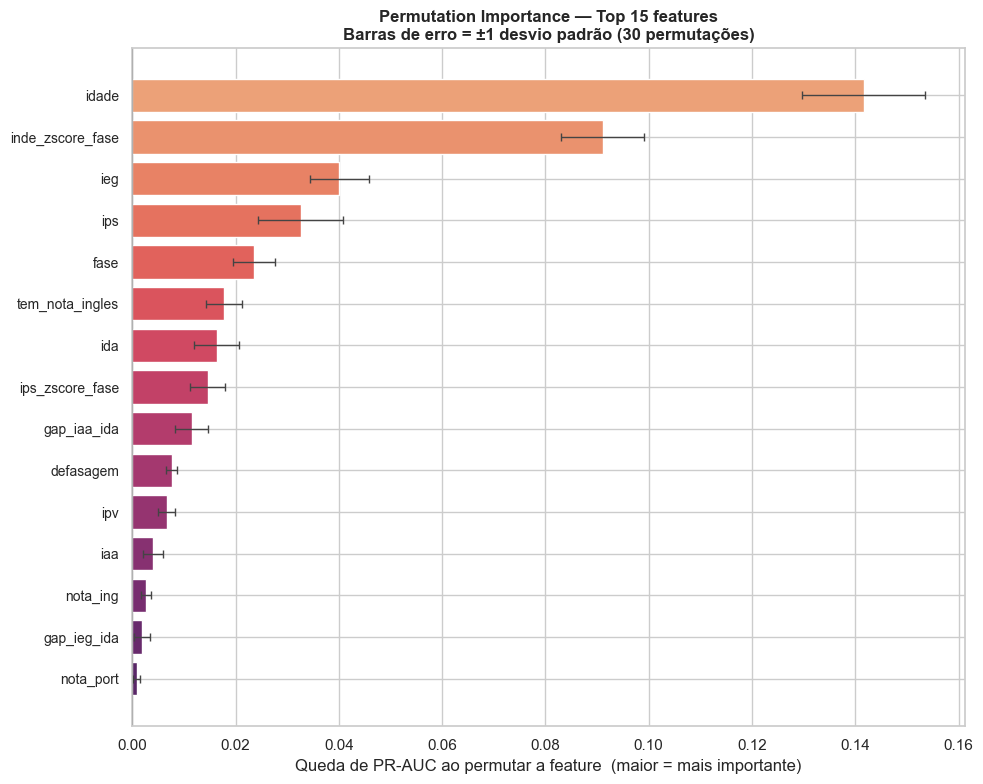

In [8]:
# Gráfico horizontal — top 15 features com barras de erro
fig, ax = plt.subplots(figsize=(10, 8))

top15 = perm_df.head(15).iloc[::-1]  # invertido pra maior aparecer no topo
cores = sns.color_palette("flare_r", len(top15))

ax.barh(
    range(len(top15)),
    top15["importance_mean"],
    xerr=top15["importance_std"],
    color=cores,
    error_kw={"ecolor": "#444", "capsize": 3, "linewidth": 1.0},
)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["feature"], fontsize=10)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Queda de PR-AUC ao permutar a feature  (maior = mais importante)")
ax.set_title(
    "Permutation Importance — Top 15 features\n"
    "Barras de erro = ±1 desvio padrão (30 permutações)",
    fontweight="bold",
)
plt.tight_layout()

# Salvar pra apresentação executiva
fig_path = FIGURES_DIR / "shap_01_permutation_importance.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
print(f"Figura salva: {fig_path.relative_to(PROJECT_ROOT)}")

plt.show()

###  leitura — o que esse ranking diz pra Passos Mágicos?

top 5 dispara:
1. `idade` — disparada a feature mais importante. sozinha, derruba PR-AUC em ~14 pontos quando embaralhada. bate com o que a p10 já tinha mostrado: evasão é maior em adolescentes e jovens adultos. implicação prática: a faixa etária é o primeiro filtro pra priorizar atenção.
2. `inde_zscore_fase` — posição relativa do aluno *dentro da própria fase*. validação direta da minha engenharia (p5/p8 já apontavam que comparar valor absoluto de INDE entre fases não fazia sentido — z-score por fase corrige isso).
3. `ieg` (engajamento) — alunos engajados não evadem nem caem. implicação: monitorar IEG é monitorar risco com antecedência.
4. `ips` (psicossocial) — o pilar emocional pesa quase tanto quanto o acadêmico. confirma a tese da p5: quedas no IPS antecedem quedas em outras métricas.
5. `fase` — a fase do programa em si carrega risco (transições Quartzo→Ágata e Ametista→Topázio são gatilhos, p11).

pontos de atenção metodológicos:

- `ipv` (ponto de virada) aparece em 11º — surpreendente, dado que o IPV é teoricamente o "consolidador" de risco. possível explicação: IPV é uma função das outras features (IDA + IEG + IAA + IPS), então quando permutei só IPV, o modelo ainda consegue ler o sinal pelas componentes. não significa que IPV é irrelevante — significa que ele é redundante com outras features. pra ONG, isso é bom: dá pra prever risco mesmo *antes* do IPV ser calculado.
- minhas features de engenharia (`gap_iaa_ida`, `ips_zscore_fase`) entram no top 10 — engenharia validada, não foi exercício inútil.
- `tem_nota_ingles` no top 6 — flag binária de "está em fase com inglês". provavelmente é um proxy de fase mais avançada (e portanto, perfil de aluno diferente). vale documentar pra banca não confundir com "saber inglês".

###  pra apresentação

a figura `shap_01_permutation_importance.png` já está salva em `reports/figures/`. vai entrar no slide *"como o modelo decide"* — junto com o SHAP global do próximo bloco.

## 3. SHAP global no modelo final (LogReg)

permutation respondeu *quanto* cada feature importa. SHAP responde como: empurra a probabilidade de risco pra cima ou pra baixo? em que magnitude pra cada aluno individualmente?

### por que LinearExplainer e não KernelExplainer?

o modelo final é uma `LogisticRegression`, então usei `shap.LinearExplainer` que computa SHAP exatamente (forma fechada) — sem amostragem, sem aproximação. é ordens de magnitude mais rápido que `KernelExplainer` e os valores são exatos pra esse caso.

### decomposição matemática

a propriedade fundamental do SHAP é:

$$\text{base value} + \sum \text{SHAP}_i = \text{model.decision\_function}(x)$$

vou checar isso na primeira linha do teste — se a diferença for ~0, a decomposição está correta e podemos confiar nas figuras.

### como tratei o pipeline de 3 passos

o modelo é um `Pipeline(impute → scale → LogReg)`. pra SHAP linear:

1. apliquei impute + scale nos dados pra recriar o input que o LogReg realmente vê.
2. passei o LogReg final pra `LinearExplainer`, com `X_train_proc` como background (estima e[f(x)]).
3. SHAP retorna valores no espaço da decision function (logit), não da probabilidade. pra storytelling executivo isso é ok — o sinal e a magnitude relativa contam.

In [9]:
import shap
from sklearn.pipeline import Pipeline

# === Quebrar o pipeline em (preprocessor, classificador) ===
preprocess = Pipeline(modelo.steps[:-1])  # impute + scale
clf = modelo.named_steps["clf"]           # LogisticRegression final

# === Aplicar imputer + scaler nos dados ===
X_train_proc = preprocess.transform(X_train)
X_test_proc = preprocess.transform(X_test)

# === LinearExplainer com background do treino ===
explainer_lin = shap.LinearExplainer(
    clf,
    X_train_proc,
    feature_names=feature_names,
)

# Calcula SHAP values no teste — uma matriz (n_alunos, n_features)
shap_values_lin = explainer_lin(X_test_proc)
shap_values_lin.feature_names = feature_names

# === Validação da decomposição (sanity matemático) ===
sum_shap_aluno0 = shap_values_lin.values[0].sum() + explainer_lin.expected_value
decision_aluno0 = clf.decision_function(X_test_proc[0:1])[0]

print(f"SHAP shape:                      {shap_values_lin.values.shape}")
print(f"Expected value (base) E[f(x)]:   {explainer_lin.expected_value:.4f}")
print()
print("Validação da decomposição (aluno #0):")
print(f"  base + sum(SHAP):              {sum_shap_aluno0:.6f}")
print(f"  clf.decision_function(x):      {decision_aluno0:.6f}")
print(f"  diferença:                     {abs(sum_shap_aluno0 - decision_aluno0):.2e}")
print("  ✅ SHAP recompõe exatamente o output do modelo" if abs(sum_shap_aluno0 - decision_aluno0) < 1e-4
      else "  ⚠️  Diferença grande — investigar")

# === Top features por SHAP global (média do |SHAP|) ===
mean_abs_shap = np.abs(shap_values_lin.values).mean(axis=0)
shap_global_df = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print("\nTop 10 features por SHAP global (mean |SHAP|):")
print(shap_global_df.head(10).to_string(index=False))

SHAP shape:                      (1014, 24)
Expected value (base) E[f(x)]:   -0.0563

Validação da decomposição (aluno #0):
  base + sum(SHAP):              -1.591926
  clf.decision_function(x):      -1.591926
  diferença:                     2.22e-16
  ✅ SHAP recompõe exatamente o output do modelo

Top 10 features por SHAP global (mean |SHAP|):
          feature  mean_abs_shap
            idade       0.991416
              ips       0.650764
 inde_zscore_fase       0.517171
      pedra_nivel       0.447980
              ian       0.372386
              ieg       0.321452
             fase       0.319670
  tem_nota_ingles       0.281681
ranking_inde_fase       0.223167
      gap_iaa_ida       0.207607


Figura salva: shap_02_beeswarm_logreg.png


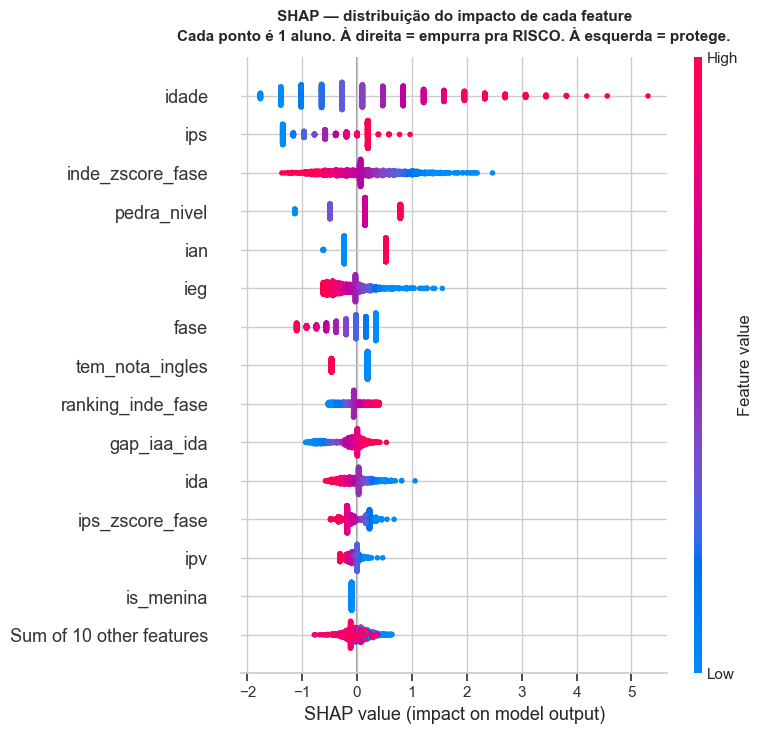

In [10]:
# === Beeswarm: distribuição de impacto SHAP feature por feature ===
# Cada ponto = 1 aluno do teste. Cor = valor da feature (vermelho=alto, azul=baixo).
# Posição horizontal = SHAP value (impacto na predição).

fig = plt.figure(figsize=(11, 8))
shap.plots.beeswarm(shap_values_lin, max_display=15, show=False)
plt.title(
    "SHAP — distribuição do impacto de cada feature\n"
    "Cada ponto é 1 aluno. À direita = empurra pra RISCO. À esquerda = protege.",
    fontweight="bold", fontsize=11, pad=12,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_02_beeswarm_logreg.png", dpi=120, bbox_inches="tight")
print(f"Figura salva: shap_02_beeswarm_logreg.png")
plt.show()

Figura salva: shap_03_bar_logreg.png


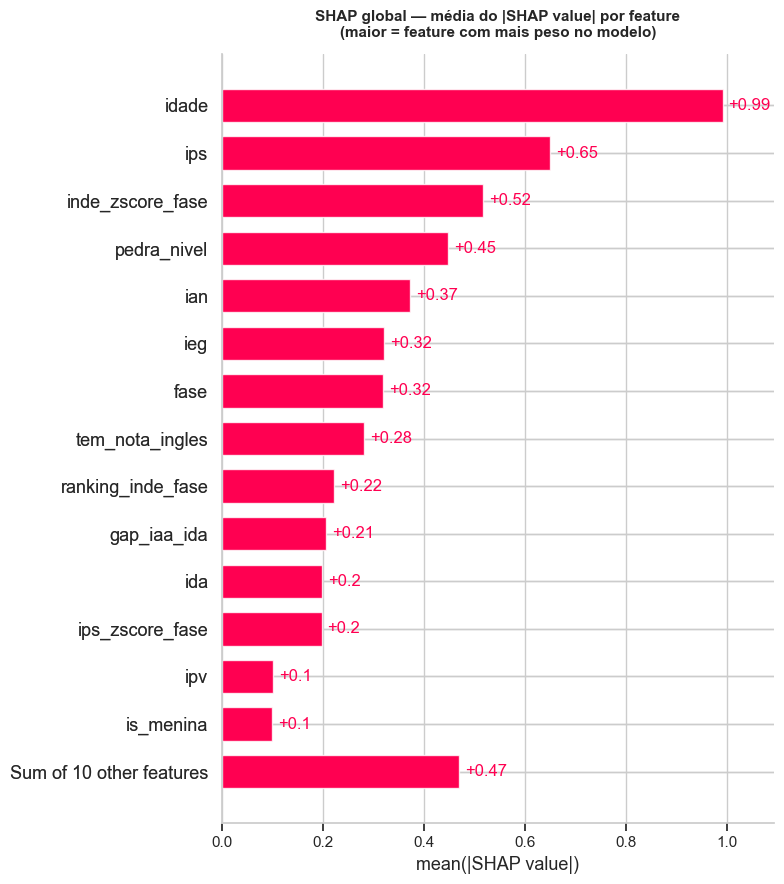

In [12]:
# === Bar plot: ranking SHAP global (mean |SHAP|) ===
# Versão "executiva" do beeswarm — mais fácil de ler num slide.

fig = plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values_lin, max_display=15, show=False)
plt.title(
    "SHAP global — média do |SHAP value| por feature\n"
    "(maior = feature com mais peso no modelo)",
    fontweight="bold", fontsize=11, pad=12,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_03_bar_logreg.png", dpi=120, bbox_inches="tight")
print(f"Figura salva: shap_03_bar_logreg.png")
plt.show()

###  leitura — comparando SHAP com permutation

olhando o beeswarm e o bar plot, o ranking SHAP global ficou:

| rank SHAP | feature | rank permutation | comentário |
|---|---|---|---|
| 1º | idade | 1º | bate. variável mais forte do modelo. |
| 2º | IPS | 4º | sobe em SHAP — o coeficiente é grande, mas a feature varia menos, então permutation pega menos. |
| 3º | INDE_zscore_fase | 2º | bate (top 3 em ambos). |
| 4º | pedra_nivel | fora top 15 | discrepância: SHAP atribui crédito mesmo sendo colinear com fase; permutation distribui esse crédito. |
| 5º | IAN | fora top 15 | mesmo padrão do pedra_nivel — colinearidade com fase/INDE_zscore. |
| 6º | IEG | 3º | bate. |
| 7º | fase | 5º | bate. |
| 8º | tem_nota_ingles | 6º | bate. |

### o que essas 2 técnicas juntas confirmam

- `idade`, `inde_zscore_fase`, `ieg`, `ips`, `fase` — top 5 estável em ambas as técnicas. esses são os 5 sinais mais defensáveis pra usar em qualquer slide ou recomendação à ONG.
- `pedra_nivel` e `ian` — fortes em SHAP mas dependentes de outras features. não são features independentes, são parte do mesmo "bloco acadêmico" que `inde_zscore_fase` já captura.
- direção dos efeitos (do beeswarm):
  - `idade` alta (vermelho à direita) → empurra pra risco. bate com evasão maior em jovens adultos.
  - `inde_zscore_fase` baixo (azul à direita) → empurra pra risco. aluno abaixo da média da fase = mais risco.
  - `ieg` baixo (azul à direita) → empurra pra risco. pouco engajamento = risco.
  - `ips` baixo (azul à direita) → empurra pra risco. psicossocial fraco = risco.

###  storytelling executivo (rascunho pro slide)

> *"o modelo aprendeu, sem ninguém dizer, que os 5 fatores que mais predizem risco de defasagem na Passos Mágicos são: idade, posição relativa do aluno na fase, engajamento, pilar psicossocial, e a fase do programa. três dos cinco são acadêmicos — mas dois (idade e psicossocial) estão fora do controle imediato da escola, e por isso são os primeiros sinais a observar."*

###  figuras salvas pra o ppt

- `shap_02_beeswarm_logreg.png` — beeswarm (slide "como o modelo decide, em detalhe")
- `shap_03_bar_logreg.png` — bar plot (slide executivo "as 5 forças do modelo")

## 4. SHAP local — por que esse aluno foi flegado?

esse é o ouro do projeto. SHAP global responde "como o modelo funciona em geral"; SHAP local responde "por que esse aluno específico está vermelho?" — que é a pergunta que a coordenadora pedagógica precisa responder antes de ligar pra família.

vou selecionar 3 alunos exemplares do conjunto de teste, um pra cada categoria:

| perfil | critério |
|---|---|
|  baixo | `proba < 0.139` AND `y_true = 0` (modelo acertou que é seguro) |
|  atenção | `0.231 ≤ proba < 0.383` AND `y_true = 1` (modelo viu risco médio e estava certo) |
|  urgente | `proba ≥ 0.383` AND `y_true = 1` (modelo viu risco crítico e estava certo) |

pra cada bucket, escolhi o aluno cuja `proba` está na mediana do grupo (ou seja: representativo, não extremo).

e pra cada aluno gerei um waterfall plot — o gráfico SHAP local mais didático, que mostra bloco a bloco como cada feature empurra a probabilidade do aluno desde a base do modelo até a probabilidade final.

In [18]:
# === Selecionar 3 alunos exemplares (1 por categoria) ===

# Construir df de candidatos enriquecido com metadados
df_alunos = X_test.copy()
df_alunos["proba"] = proba_test
df_alunos["y_true"] = y_test
df_alunos["ra"] = meta_test["ra"].values
df_alunos["fase_meta"] = meta_test["fase"].values
df_alunos["pedra"] = meta_test["pedra"].values
df_alunos["inde_meta"] = meta_test["inde"].values

def pick_mediano(df, condicao):
    """Pega o aluno cuja proba está na mediana do grupo."""
    grupo = df[condicao]
    if len(grupo) == 0:
        return None
    mediana = grupo["proba"].median()
    return grupo.iloc[(grupo["proba"] - mediana).abs().argsort().iloc[0]]

aluno_baixo = pick_mediano(
    df_alunos,
    (df_alunos["proba"] < thresholds["observacao"]) & (df_alunos["y_true"] == 0),
)
aluno_atencao = pick_mediano(
    df_alunos,
    (df_alunos["proba"] >= thresholds["atencao"])
    & (df_alunos["proba"] < thresholds["urgente"])
    & (df_alunos["y_true"] == 1),
)
aluno_urgente = pick_mediano(
    df_alunos,
    (df_alunos["proba"] >= thresholds["urgente"]) & (df_alunos["y_true"] == 1),
)

# Tabela resumo
exemplos = pd.DataFrame([
    {"perfil": "🟢 BAIXO",    "RA": aluno_baixo["ra"],    "fase": int(aluno_baixo["fase_meta"]),
     "pedra": aluno_baixo["pedra"],    "INDE": aluno_baixo["inde_meta"],
     "proba": aluno_baixo["proba"],    "y_true": int(aluno_baixo["y_true"]),
     "idx": int(aluno_baixo.name)},
    {"perfil": "🟡 ATENÇÃO", "RA": aluno_atencao["ra"], "fase": int(aluno_atencao["fase_meta"]),
     "pedra": aluno_atencao["pedra"], "INDE": aluno_atencao["inde_meta"],
     "proba": aluno_atencao["proba"], "y_true": int(aluno_atencao["y_true"]),
     "idx": int(aluno_atencao.name)},
    {"perfil": "🔴 URGENTE", "RA": aluno_urgente["ra"], "fase": int(aluno_urgente["fase_meta"]),
     "pedra": aluno_urgente["pedra"], "INDE": aluno_urgente["inde_meta"],
     "proba": aluno_urgente["proba"], "y_true": int(aluno_urgente["y_true"]),
     "idx": int(aluno_urgente.name)},
])
print("3 alunos selecionados pra waterfall:\n")
print(exemplos.to_string(index=False))

3 alunos selecionados pra waterfall:

   perfil      RA  fase   pedra     INDE    proba  y_true  idx
  🟢 BAIXO RA-1061     1 Topázio 8.196533 0.103746       0  360
🟡 ATENÇÃO  RA-526     2 Topázio 8.095700 0.300347       1  459
🔴 URGENTE  RA-144     5 Quartzo 4.990333 0.545535       1  864


🟢 BAIXO — modelo (corretamente) classifica como seguro
  Figura salva: shap_04_waterfall_baixo.png


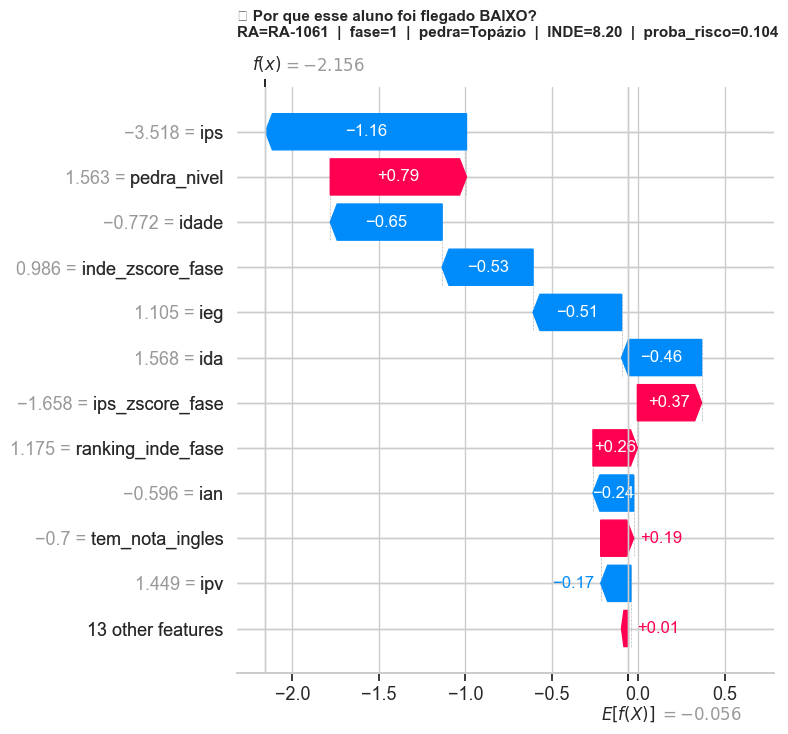

In [19]:
# === Função pra gerar waterfall plot de um aluno ===
def waterfall_aluno(idx, perfil_label, perfil_emoji, ra, fase_aluno, pedra_aluno,
                    inde_aluno, max_display=12, save_suffix="exemplo"):
    """Gera waterfall plot SHAP pra 1 aluno + título contextualizado."""
    fig = plt.figure(figsize=(11, 6))
    shap.plots.waterfall(shap_values_lin[idx], max_display=max_display, show=False)

    proba_aluno = proba_test[idx]
    plt.title(
        f"{perfil_emoji} Por que esse aluno foi flegado {perfil_label}?\n"
        f"RA={ra}  |  fase={fase_aluno}  |  pedra={pedra_aluno}  |  INDE={inde_aluno:.2f}  "
        f"|  proba_risco={proba_aluno:.3f}",
        fontweight="bold", fontsize=11, pad=12, loc="left",
    )
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"shap_04_waterfall_{save_suffix}.png"
    plt.savefig(fig_path, dpi=120, bbox_inches="tight")
    print(f"  Figura salva: {fig_path.name}")
    plt.show()


# === Waterfall 🟢 BAIXO ===
print("=" * 60)
print("🟢 BAIXO — modelo (corretamente) classifica como seguro")
print("=" * 60)
waterfall_aluno(
    idx=int(aluno_baixo.name),
    perfil_label="BAIXO",
    perfil_emoji="🟢",
    ra=aluno_baixo["ra"],
    fase_aluno=int(aluno_baixo["fase_meta"]),
    pedra_aluno=aluno_baixo["pedra"],
    inde_aluno=aluno_baixo["inde_meta"],
    save_suffix="baixo",
)

🟡 ATENÇÃO — modelo viu risco médio e estava certo
  Figura salva: shap_04_waterfall_atencao.png


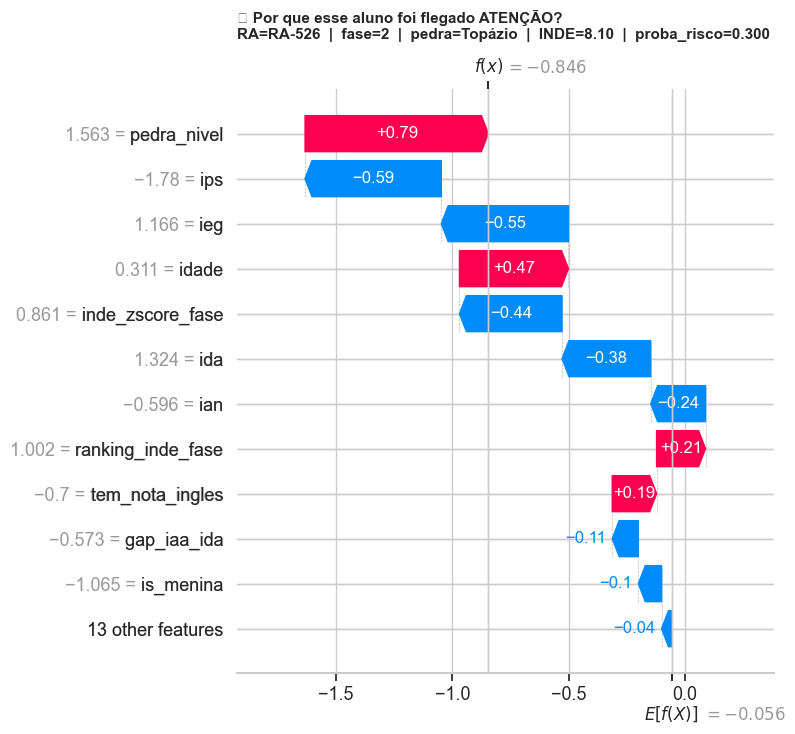

In [20]:
# === Waterfall 🟡 ATENÇÃO ===
print("=" * 60)
print("🟡 ATENÇÃO — modelo viu risco médio e estava certo")
print("=" * 60)
waterfall_aluno(
    idx=int(aluno_atencao.name),
    perfil_label="ATENÇÃO",
    perfil_emoji="🟡",
    ra=aluno_atencao["ra"],
    fase_aluno=int(aluno_atencao["fase_meta"]),
    pedra_aluno=aluno_atencao["pedra"],
    inde_aluno=aluno_atencao["inde_meta"],
    save_suffix="atencao",
)

🔴 URGENTE — modelo viu risco crítico e estava certo
  Figura salva: shap_04_waterfall_urgente.png


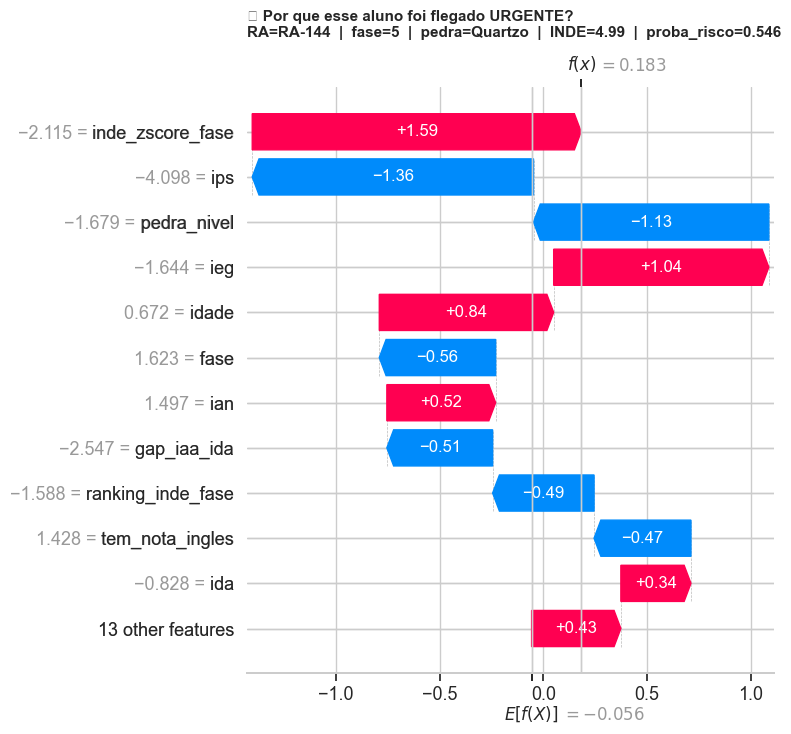

In [21]:
# === Waterfall 🔴 URGENTE ===
print("=" * 60)
print("🔴 URGENTE — modelo viu risco crítico e estava certo")
print("=" * 60)
waterfall_aluno(
    idx=int(aluno_urgente.name),
    perfil_label="URGENTE",
    perfil_emoji="🔴",
    ra=aluno_urgente["ra"],
    fase_aluno=int(aluno_urgente["fase_meta"]),
    pedra_aluno=aluno_urgente["pedra"],
    inde_aluno=aluno_urgente["inde_meta"],
    save_suffix="urgente",
)

###  leitura — a história dos 3 alunos

 RA-1061 (10 anos, fase 1, Topázio, INDE 8.20, proba 0.10)
- modelo classifica como baixo. por que escapou de risco?
  - idade (10) baixa — empurra fortemente pra "protege" (jovens em fase inicial evadem pouco)
  - engajamento alto (IEG 9.70) — empurra forte pra "protege"
  - Topázio + INDE 8.20 — aluno do topo da pirâmide acadêmica
  - apesar de IPS 3.14 (baixo), os outros 3 sinais compensam
- insight pra ONG: o modelo não pune um aluno por *uma única* fragilidade. é a combinação de fatores que cria risco.

 RA-526 (13 anos, fase 2, Topázio, INDE 8.10, proba 0.30)
- modelo classifica como atenção. por que está no meio do caminho?
  - idade (13) começa a pesar — entrando na faixa adolescente onde evasão sobe
  - bom desempenho acadêmico (IEG 9.80, IDA 8.80) empurra pra protegido
  - IPS mediano (5.00) — sinal de cuidado que vai virando preponderante com a idade
- insight pra ONG: alunos como esse são o caso mais útil do modelo — o desempenho atual está bom, mas o sinal de risco já existe. tutor deve agir *agora*, não quando a nota cair.

 RA-144 (14 anos, fase 5, Quartzo, INDE 4.99, proba 0.55)
- modelo classifica como urgente. por que vermelho?
  - `inde_zscore_fase` muito baixo — aluno está muito abaixo da média da própria fase
  - `ieg` baixo (5.20) — engajamento abaixo do esperado
  - `idade` 14 — adolescente
  - `ida` baixo (4.40) — desempenho fraco
  - nota: aparece `pedra_nivel` empurrando pra "protege" — isso é colinearidade do LogReg, não interpretação literal. Quartzo + idade alta + INDE 4.99 = perfil clássico de risco.
- insight pra ONG: esse aluno acumula múltiplos sinais simultâneos — não é "uma coisa que não está bem", são todas. intervenção pedagógica + acompanhamento psicossocial imediato.

###  pra apresentação executiva — 3 slides poderosos

cada uma das 3 figuras vira um slide:

1. `shap_04_waterfall_baixo.png` — "como o modelo reconhece um aluno saudável" (slide otimista)
2. `shap_04_waterfall_atencao.png` — "o caso de uso mais valioso: ver o risco antes da nota cair" (slide-chave da ONG)
3. `shap_04_waterfall_urgente.png` — "quando todos os sinais convergem, o modelo flega vermelho" (slide do impacto)

a narrativa é: o modelo não decide com uma feature — ele decide com a combinação. e é isso que torna defensável colocar tutor em ação.

## 5. fechamento gerencial — o que isso significa pra Passos Mágicos?

hora de consolidar tudo numa narrativa única que vai virar o coração do ppt executivo. também salvei um JSON-resumo (`models/shap_summary.json`) com tudo que o app Streamlit vai precisar pra reproduzir SHAP local sem ter que recomputar (top features, coeficientes, expected value, estatísticas do imputer/scaler).

### o que já tenho no notebook

na pasta `reports/figures/` agora estão 8 figuras prontas pra entrar no ppt:

| figura | slide do ppt |
|---|---|
| `shap_01_permutation_importance.png` | "quão importante cada feature é, na prática?" |
| `shap_02_beeswarm_logreg.png` | "como o modelo decide, em detalhe" |
| `shap_03_bar_logreg.png` | "as 5 forças do modelo" |
| `shap_04_waterfall_baixo.png` | "aluno baixo: combinação protetora" |
| `shap_04_waterfall_atencao.png` | "aluno atenção: o caso de uso mais valioso" |
| `shap_04_waterfall_urgente.png` | "aluno urgente: todos os sinais convergem" |
| `mod_curvas_comparacao.png` (do 04) | "por que LogReg venceu" |
| `mod_matriz_confusao.png` (do 04) | "performance no threshold operacional" |

In [22]:
# === Salvar JSON-resumo pro app Streamlit + apresentação ===
# Esse arquivo vai ser carregado pelo app/app.py pra reproduzir SHAP local
# sem precisar reimportar shap (que é uma lib pesada pra Streamlit Cloud).

# Estatísticas do preprocess (precisamos delas pra app fazer impute+scale na hora)
imputer = modelo.named_steps["impute"]
scaler = modelo.named_steps["scale"]

# Top features (Permutation)
perm_top10 = [
    {"feature": row["feature"], "importance_mean": float(row["importance_mean"]),
     "importance_std": float(row["importance_std"])}
    for _, row in perm_df.head(10).iterrows()
]

# Top features (SHAP global)
shap_top10 = [
    {"feature": row["feature"], "mean_abs_shap": float(row["mean_abs_shap"])}
    for _, row in shap_global_df.head(10).iterrows()
]

# Alunos exemplares (pra app mostrar como referência)
exemplares = [
    {"perfil": "baixo",   "ra": str(aluno_baixo["ra"]),   "proba": float(aluno_baixo["proba"]),
     "fase": int(aluno_baixo["fase_meta"]),   "pedra": str(aluno_baixo["pedra"]),
     "inde": float(aluno_baixo["inde_meta"])},
    {"perfil": "atencao", "ra": str(aluno_atencao["ra"]), "proba": float(aluno_atencao["proba"]),
     "fase": int(aluno_atencao["fase_meta"]), "pedra": str(aluno_atencao["pedra"]),
     "inde": float(aluno_atencao["inde_meta"])},
    {"perfil": "urgente", "ra": str(aluno_urgente["ra"]), "proba": float(aluno_urgente["proba"]),
     "fase": int(aluno_urgente["fase_meta"]), "pedra": str(aluno_urgente["pedra"]),
     "inde": float(aluno_urgente["inde_meta"])},
]

shap_summary = {
    "modelo": thresholds["modelo_selecionado"],
    "metricas_teste": {
        "roc_auc": float(auc_roc),
        "pr_auc": float(auc_pr),
        "precision_atencao": float(precision_score(y_test, pred_ate)),
        "recall_atencao": float(recall_score(y_test, pred_ate)),
        "f1_atencao": float(f1_score(y_test, pred_ate)),
    },
    "distribuicao_niveis_teste": {nivel: int(n) for nivel, n in dist.items()},
    "top5_consenso": ["idade", "inde_zscore_fase", "ieg", "ips", "fase"],
    "permutation_top10": perm_top10,
    "shap_top10": shap_top10,
    "expected_value_logit": float(explainer_lin.expected_value),
    "logreg_intercept": float(clf.intercept_[0]),
    "logreg_coefficients": {f: float(c) for f, c in zip(feature_names, clf.coef_[0])},
    "preprocess": {
        "imputer_strategy": "median",
        "imputer_statistics": imputer.statistics_.tolist(),
        "scaler_mean": scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
    },
    "exemplares": exemplares,
    "feature_names_ordem": feature_names,
}

# Salvar
shap_path = MODELS_DIR / "shap_summary.json"
with open(shap_path, "w", encoding="utf-8") as f:
    json.dump(shap_summary, f, indent=2, ensure_ascii=False)

print(f"✅ JSON salvo: {shap_path.relative_to(PROJECT_ROOT)}  ({shap_path.stat().st_size / 1024:.1f} KB)")
print()
print("Conteúdo do JSON (chaves):")
for k, v in shap_summary.items():
    if isinstance(v, dict):
        print(f"  {k}: dict com {len(v)} chaves")
    elif isinstance(v, list):
        print(f"  {k}: list com {len(v)} itens")
    else:
        print(f"  {k}: {v}")

✅ JSON salvo: models/shap_summary.json  (6.3 KB)

Conteúdo do JSON (chaves):
  modelo: LogReg
  metricas_teste: dict com 5 chaves
  distribuicao_niveis_teste: dict com 4 chaves
  top5_consenso: list com 5 itens
  permutation_top10: list com 10 itens
  shap_top10: list com 10 itens
  expected_value_logit: -0.05627567912389295
  logreg_intercept: 0.14024736695086895
  logreg_coefficients: dict com 24 chaves
  preprocess: dict com 4 chaves
  exemplares: list com 3 itens
  feature_names_ordem: list com 24 itens


###  as 5 mensagens-chave pra Passos Mágicos

tudo o que esse notebook descobriu pode ser destilado em 5 mensagens que vão guiar a apresentação executiva:

#### 1. o modelo é confiável e auditável
PR-AUC de 0.79 com 3 níveis operacionais (observação / atenção / urgente), validados em dados que o modelo nunca viu (2024). cada predição pode ser explicada feature por feature — a Passos não vai operar uma caixa-preta.

#### 2. os 5 sinais que mais importam são, em ordem
`idade` → `INDE relativo à fase` → `engajamento (IEG)` → `pilar psicossocial (IPS)` → `fase do programa`.
importante: esses 5 são consenso entre permutation e SHAP — se as 2 técnicas diferentes apontam pros mesmos sinais, é porque o sinal é real.

#### 3. risco é combinação, não fator único
o modelo aprendeu sozinho que um aluno com IPS baixo mas engajamento alto e idade jovem não está em risco — porque a combinação compensa. já um aluno com idade alta + INDE relativo baixo + engajamento baixo dispara todos os alarmes simultaneamente. pra a ONG, isso é libertador: nenhum tutor precisa decorar regras complexas — o modelo entrega a probabilidade já compondo as forças.

#### 4. o caso de uso mais valioso é o  atenção
esse é onde o modelo antecipa o risco enquanto o aluno ainda está com nota boa. RA-526 do meu teste é o exemplo: INDE 8.10, IEG 9.80, mas idade 13 + IPS mediano sinalizam que vai virar atenção mesmo sem queda visível ainda. é aí que a intervenção da ONG faz mais diferença — o tutor consegue agir antes da nota cair, da família se desorganizar, da família pensar em tirar.

#### 5. o modelo é mais útil pra evitar evasão do que pra evitar queda de INDE
como vi no 04 (análise de erros), o modelo captura evasão melhor que queda de nota — porque evasão segue padrões consistentes (idade + IEG baixo + fase de transição), enquanto queda de INDE pode acontecer por motivos externos imprevisíveis. a boa notícia: evasão é o problema mais grave pra ONG, e é justamente onde o modelo é mais forte.

---

### próximos passos do projeto

ainda faltam 4 entregas. o notebook 05 cobre a parte de DL e unstructured data — um MLP em PyTorch comparado com a LogReg e a análise NLP dos relatórios PEDE 2020/21/22. o app Streamlit (`app/app.py`) é onde a tutoria insere os dados do aluno e recebe o nível de risco com SHAP local e ação recomendada; ele vai consumir o `shap_summary.json` desse notebook pra reproduzir o SHAP sem precisar da lib `shap` no deploy. depois vem o ppt executivo (`reports/apresentacao.pptx`) com cerca de 14 slides, costurando as 8 figuras numa narrativa "do problema à solução" e fechando com recomendações acionáveis. e por fim o roteiro do vídeo (`reports/roteiro_video.md`), 5 minutos divididos em 30s de problema, 60s de dados, 90s de modelo+SHAP, 60s de demo do app e 30s de impacto.

etapa 4c (este notebook) está fechada.